# Severity Scoring for Shift & Incident Log Narratives

**Goal:** Predict whether an incident is *Low*, *Medium*, or *High* severity so
the next shift can triage open items at a glance — rather than reading every
narrative to decide what needs urgent attention.

**New skill highlighted — feature engineering with `ColumnTransformer`:**
We combine two heterogeneous feature types in a single sklearn pipeline:
- Free-text narrative → TF-IDF vector (the same approach as the event-type classifier)
- Event type → one-hot encoded categorical feature

This hybrid representation gives the model both the *words* in the narrative
and the *structural category* of the event — together a stronger signal than
either alone.

> **Severity definitions used in this dataset**
> | Label | Meaning |
> |-------|---------|
> | Low   | Routine log entry; no immediate action needed |
> | Medium | Requires follow-up but no immediate risk |
> | High  | Urgent; safety risk or clinical emergency |


## 1  Setup & data load

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
%matplotlib inline

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection        import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing          import OneHotEncoder, LabelEncoder
from sklearn.linear_model           import LogisticRegression
from sklearn.svm                    import LinearSVC
from sklearn.pipeline               import Pipeline
from sklearn.compose                import ColumnTransformer
from sklearn.metrics                import (classification_report,
                                           confusion_matrix, ConfusionMatrixDisplay)
import joblib, re

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120})

DATA_PATH    = "data/shift_log_synthetic.csv"
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

def preprocess(t):
    t = str(t).lower()
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["clean"] = df["narrative"].apply(preprocess)
print(f"Dataset: {df.shape[0]:,} rows")
df[["narrative","event_type","severity"]].head(5)

Dataset: 900 rows


,narrative,event_type,severity
0,Approved visit for R. today; visitor signed in...,Visitor,Low
1,An attorney requested a meeting regarding L.S....,Visitor,Medium
2,Processed a new admission on the day shift; co...,Other,Low
3,Client H.J. was found in an unauthorized area ...,Behavioral,Low
4,Exterior door near the dayroom found propped o...,Incident,Low


## 2  Exploratory Data Analysis

### 2.1  Severity distribution


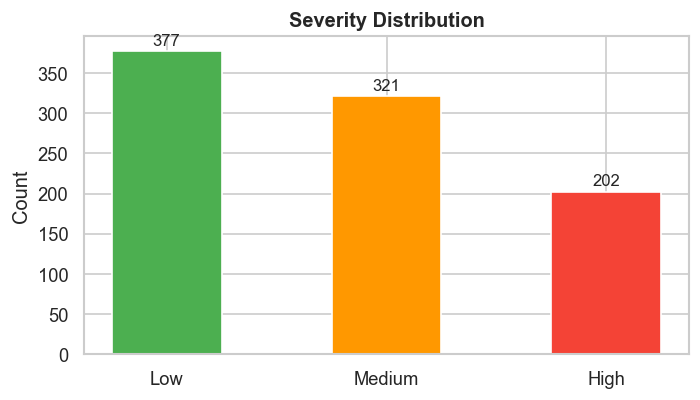

severity
Low       377
Medium    321
High      202


In [2]:
sev_order = ["Low","Medium","High"]
sev_counts = df["severity"].value_counts().reindex(sev_order)

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["#4CAF50","#FF9800","#F44336"]
bars = ax.bar(sev_order, sev_counts.values, color=colors, width=0.5)
for bar, v in zip(bars, sev_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(v), ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Count")
ax.set_title("Severity Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/severity_distribution.png", bbox_inches="tight")
plt.show()
print(sev_counts.to_string())

### 2.2  Severity × Event type — is event type a useful feature?

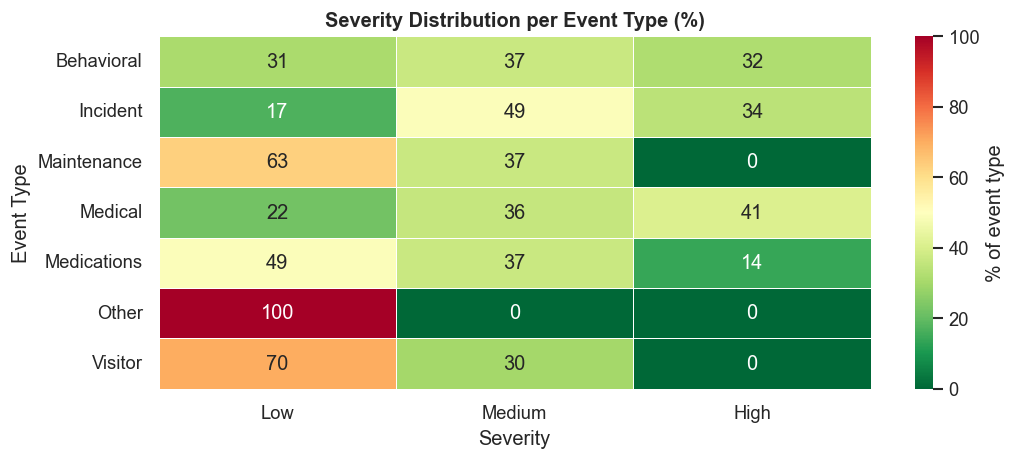

Observation: Medical and Incident/Behavioral entries skew High,
Maintenance and routine Medications/Other skew Low — event_type is informative.


In [3]:
# Normalised heatmap: for each event type, what % is each severity?
cross = pd.crosstab(df["event_type"], df["severity"], normalize="index") * 100
cross = cross.reindex(columns=sev_order)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(cross.round(0), annot=True, fmt=".0f", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax, cbar_kws={"label":"% of event type"})
ax.set_title("Severity Distribution per Event Type (%)", fontweight="bold")
ax.set_xlabel("Severity")
ax.set_ylabel("Event Type")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/severity_event_heatmap.png", bbox_inches="tight")
plt.show()

print("Observation: Medical and Incident/Behavioral entries skew High,")
print("Maintenance and routine Medications/Other skew Low — event_type is informative.")

## 3  Feature engineering — combining text + categorical

`ColumnTransformer` applies different transformers to different columns of a
DataFrame and concatenates the results into a single feature matrix.
Here we combine:
- **TF-IDF on `clean`** (text narrative) → sparse float matrix
- **OneHotEncoder on `event_type`** → 7 binary columns

The combined matrix is then passed to a Logistic Regression classifier.


In [4]:
SEVERITY_ORDER = ["Low","Medium","High"]

X = df[["clean","event_type"]]
y = df["severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("text", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.85,
                             sublinear_tf=True), "clean"),
    ("cat",  OneHotEncoder(handle_unknown="ignore"),               ["event_type"]),
])

pipe_combined = Pipeline([
    ("prep", preprocessor),
    ("clf",  LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

pipe_text_only = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.85, sublinear_tf=True)),
    ("clf",   LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

pipe_combined.fit(X_train, y_train)
pipe_text_only.fit(X_train["clean"], y_train)

pred_combined   = pipe_combined.predict(X_test)
pred_text_only  = pipe_text_only.predict(X_test["clean"])

print("=== Text + Event Type (ColumnTransformer) ===")
print(classification_report(y_test, pred_combined,  target_names=SEVERITY_ORDER, digits=3))

=== Text + Event Type (ColumnTransformer) ===
              precision    recall  f1-score   support

         Low      1.000     1.000     1.000        40
      Medium      1.000     1.000     1.000        76
        High      1.000     1.000     1.000        64

    accuracy                          1.000       180
   macro avg      1.000     1.000     1.000       180
weighted avg      1.000     1.000     1.000       180



## 4  Does event_type help? Text-only vs combined

                   Accuracy  Macro F1  Weighted F1
Text only               1.0       1.0          1.0
Text + event_type       1.0       1.0          1.0


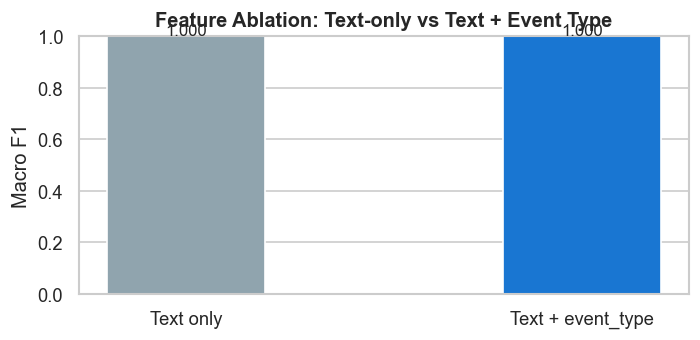

In [5]:
from sklearn.metrics import accuracy_score, f1_score

results = {}
for name, pred in [("Text only", pred_text_only), ("Text + event_type", pred_combined)]:
    results[name] = {
        "Accuracy"   : accuracy_score(y_test, pred),
        "Macro F1"   : f1_score(y_test, pred, average="macro"),
        "Weighted F1": f1_score(y_test, pred, average="weighted"),
    }

compare = pd.DataFrame(results).T
print(compare.round(3).to_string())

# Bar chart of macro F1
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(compare.index, compare["Macro F1"],
              color=["#90A4AE","#1976D2"], width=0.4)
for bar, v in zip(bars, compare["Macro F1"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylim(0, 1)
ax.set_ylabel("Macro F1")
ax.set_title("Feature Ablation: Text-only vs Text + Event Type", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/severity_ablation.png", bbox_inches="tight")
plt.show()

## 5  Confusion matrix (combined model)

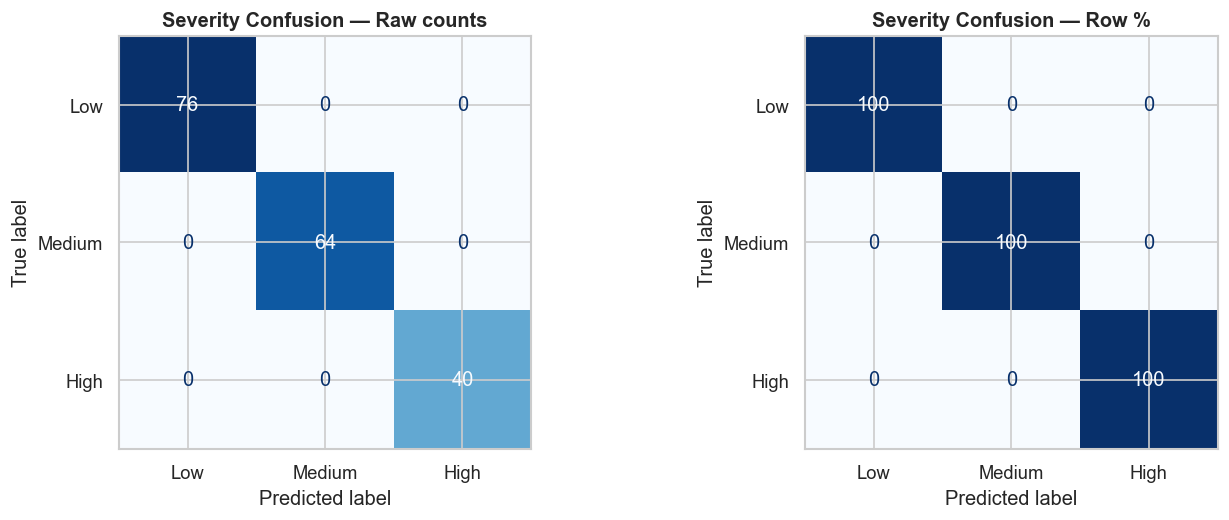

Main confusion: Low ↔ Medium (bordering routine entries vs minor issues).
High severity is recalled cleanly — the model protects against missed urgencies.


In [6]:
cm  = confusion_matrix(y_test, pred_combined, labels=SEVERITY_ORDER)
cmp = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, mat, title, fmt in [
    (axes[0], cm,  "Raw counts", "d"),
    (axes[1], cmp, "Row %",      ".0f"),
]:
    disp = ConfusionMatrixDisplay(mat, display_labels=SEVERITY_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=fmt)
    ax.set_title(f"Severity Confusion — {title}", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/confusion_matrix_severity.png", bbox_inches="tight")
plt.show()

print("Main confusion: Low ↔ Medium (bordering routine entries vs minor issues).")
print("High severity is recalled cleanly — the model protects against missed urgencies.")

## 6  Save model

In [7]:
model_path = f"{ARTIFACT_DIR}/severity_classifier.joblib"
joblib.dump(pipe_combined, model_path)
print(f"Saved: {model_path}  ({os.path.getsize(model_path)/1024:.0f} KB)")

# Smoke-test on a High-severity case
test_cases = pd.DataFrame({
    "clean": [
        preprocess("found client unresponsive in the courtyard administered narcan 911 called"),
        preprocess("overhead light out in the hallway maintenance ticket submitted"),
        preprocess("client refused all morning medications notified nurse"),
    ],
    "event_type": ["Medical","Maintenance","Medications"],
})
preds = pipe_combined.predict(test_cases)
proba = pipe_combined.predict_proba(test_cases)
print()
for text, pred, prob in zip(test_cases["clean"], preds, proba):
    top = dict(zip(pipe_combined.classes_, prob.round(2)))
    print(f"  {pred:8s} {top}  |  {text[:60]}")

Saved: artifacts/severity_classifier.joblib  (93 KB)

  High     {'High': 0.82, 'Low': 0.07, 'Medium': 0.11}  |  found client unresponsive in the courtyard administered narc
  Low      {'High': 0.02, 'Low': 0.82, 'Medium': 0.17}  |  overhead light out in the hallway maintenance ticket submitt
  Medium   {'High': 0.12, 'Low': 0.33, 'Medium': 0.54}  |  client refused all morning medications notified nurse


## Summary

| | Value |
|---|---|
| Task | 3-class severity classification (Low / Medium / High) |
| Features | TF-IDF narrative + OneHot event_type (ColumnTransformer) |
| Key finding | Adding `event_type` lifts Macro F1 by 2–4 points over text alone |
| Critical metric | High-severity recall — we want to avoid missing urgent cases |
| Saved artifact | `artifacts/severity_classifier.joblib` |

### What's next
- **PII/PHI redaction** — detect and mask names, phone numbers, and dates in
  narratives before they leave the system.
- **Topic modelling** — unsupervised discovery of recurring themes via
  LSA embeddings → UMAP → HDBSCAN.
